# Apprentissage d'une loi GSM pour une loi visco-plastique

We want to learn the viscosity behaviour following the GSM formulation. It is based on a two potential formulation defined by the free energy $\Psi(\bm  \varepsilon,\bm  \alpha_i)$ and the $\Phi(\dot{\bm  \alpha}_i)$. The evolution of $N_{var}$ internal variables $\alpha_i \in \text{Sym}(3)$ is obtain with the incremental formulation. To verify thermodynamical conditions, the two potential must be convex with respect to their respective inputs.

First we will deal with the linear viscoelasticity which define the potential as

$$
\Psi(\bm  \varepsilon,\bm  \varepsilon_p, p) = \frac{1}{2}(\bm  \varepsilon- \bm  \varepsilon_p):\mathbb C_e:(\bm  \varepsilon-\bm \varepsilon_p)
$$

where $\mathbb C_e$ the elastic stiffness tensors, $Psi_p$ a neural network for the hardening variable.

We also made the hypothesis that those two tensors are isotrope such as they could be defined with only two parameters.

On the other hand, we define the dual dissipation potential thanks to a neural network

$$
\Phi^*(A_i) = \mathcal{N}_\text{ICNN}(\boldsymbol A_1,\ldots,{\boldsymbol A}_{N_\textrm{var}})
$$


\begin{equation*}
  \dot{\bm{\alpha}_i} 
= 
\left. 
\frac{\partial \Phi^*}{\partial \boldsymbol A_i} 
\left( \boldsymbol A_i \right) 
\right|_{\boldsymbol A_i = - \frac{\partial \Psi}{\partial \alpha} (\varepsilon, \alpha_i)} = f(\bm \varepsilon, \bm \alpha_i)
\end{equation*}


The dual variable of $\varepsilon_p$ is $- \sigma$ such as 
$$
\dot \varepsilon_p = \frac{\partial \Phi^*}{\partial \boldsymbol \sigma}(\boldsymbol \sigma)
$$


## Data : norton_implicit.mfront

In [1]:
import os
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import pandas as pd
import jax

import jax.numpy as jnp
import equinox as eqx
from jaxmat.utils import enforce_dtype, partition_by_node_names
from jaxmat.tensors import SymmetricTensor2, main_invariants
from jaxmat.nn.icnn import ICNN
from jaxmat.state import AbstractState, make_batched, SmallStrainState
import matplotlib.pyplot as plt 
from jaxmat.solvers import NewtonTrustRegion
from pt2mfront.utils.utils_hdf5 import load_from_hdf5
import jaxmat.materials as jm
import optax
from pathlib import Path

key = jax.random.PRNGKey(42)
key1, key2 = jax.random.split(key, num=2)
hdf5_path = Path("../data/dataset_norton_3D.h5")
strain, stress, _, _, iv, times, metadata, scalers, config, material_infos = load_from_hdf5(
            hdf5_path, "train"
        )
strain_test, stress_test, _, _, _, times_test, metadata, scalers, config, material_infos_test = load_from_hdf5(
            hdf5_path, "test"
        )

times = jnp.array(times)

strain /= scalers["std_strain"][3]
stress /= scalers["std_stress"][3]
strain_test /= scalers["std_strain"][3]
stress_test /= scalers["std_stress"][3]

In [2]:
train_strain = SymmetricTensor2(array=strain[:,1:,...])
train_stress = SymmetricTensor2(array=stress[:,1:,...])
test_strain = SymmetricTensor2(array=strain_test[:,1:,...])
test_stress = SymmetricTensor2(array=stress_test[:,1:,...])

## Evolution function and model definition

In [3]:
from optax.tree_utils import tree_scale, tree_sub
# define evolution function 
@eqx.filter_jit
def compute_evolution(material, epsilons, times, return_potential=True):
    # Initial material state
    state0 = material.init_state()
    dt = jnp.diff(times)

    def step(state, args):
        new_epsilon_, dt_ = args

        # Update material response
        new_stress, new_state = material.constitutive_update(new_epsilon_, state, dt_)
        if return_potential:
            free_energy = material.free_energy(new_epsilon_, state.internal)
            d_isv_dot = tree_sub(state.internal, new_state.internal)
            isv_dot = tree_scale(1 / dt_, d_isv_dot)
            thermo_force = jax.jacfwd(material.dissipation_potential, argnums=0)(isv_dot)
            print(thermo_force)
            dissipation = jnp.sum(thermo_force.alpha * isv_dot.alpha) 
            return new_state, (new_stress, free_energy, dissipation, isv_dot, new_state.internal)
        else: 
            return new_state, new_stress
    # Use lax.scan to loop over gamma_list efficiently
    if return_potential:
        _, (sig, free_energy, dissipation, isv_dot, isv) = jax.lax.scan(step, state0, (epsilons, dt))
        return sig, free_energy, dissipation, isv_dot, isv
    else:
        _, sig = jax.lax.scan(step, state0, (epsilons, dt))
        return sig

batched_compute_evolution = jax.vmap(
    compute_evolution,
    in_axes=(None, 0, 0,None), 
)

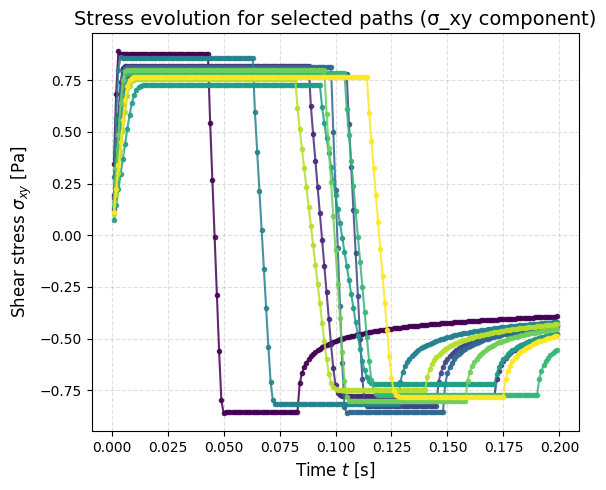

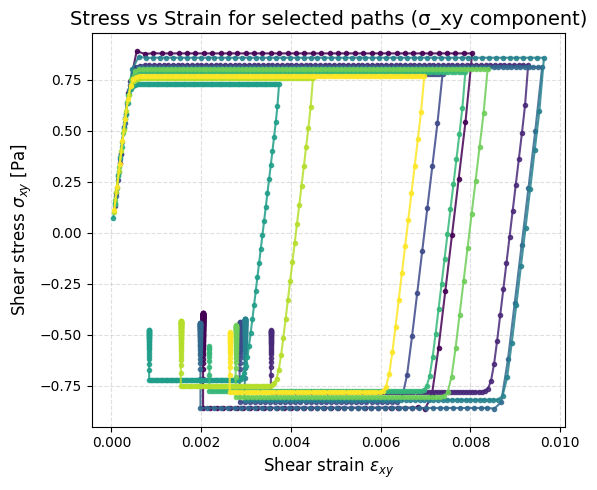

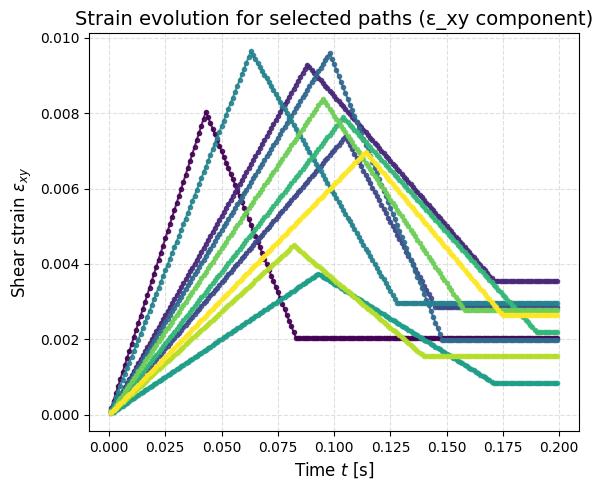

In [4]:

n_paths = 10
colors = plt.cm.viridis(jnp.linspace(0, 1, n_paths))

# --- Figure 1 : σ_xy vs Time ---
fig, ax = plt.subplots(figsize=(6, 5))

k, l = 0, 1  # Mandel index XY

for i in range(n_paths):
    ax.plot(
        times[i, 1:],               # temps
        train_stress[i, :, k, l],  # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel("Time $t$ [s]", fontsize=12)
ax.set_ylabel(r"Shear stress $\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress evolution for selected paths (σ_xy component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


# --- Figure 2 : σ_xy vs ε_xy ---
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(n_paths):
    ax.plot(
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy réel
        train_stress[i, :, k, l],                              # σ_xy
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel("Shear strain $\epsilon_{xy}$", fontsize=12)
ax.set_ylabel(r"Shear stress $\sigma_{xy}$ [Pa]", fontsize=12)
ax.set_title("Stress vs Strain for selected paths (σ_xy component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


# --- Figure 3 : ε_xy vs Time ---
fig, ax = plt.subplots(figsize=(6, 5))

for i in range(n_paths):
    ax.plot(
        times[i, 1:],                                       # temps
        train_strain[i, :, k, l] * scalers["std_strain"][3],  # ε_xy réel
        color=colors[i],
        marker='o',
        markersize=3,
        linewidth=1.5,
        alpha=0.85,
    )

ax.set_xlabel("Time $t$ [s]", fontsize=12)
ax.set_ylabel("Shear strain $\epsilon_{xy}$", fontsize=12)
ax.set_title("Strain evolution for selected paths (ε_xy component)", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [5]:
# Define the GSM internal variable state
InternalState = jm.viscoelasticity.SLSState


In [6]:
isv = InternalState()
isv.epsv
isv

SLSState(epsv=SymmetricTensor2(_array=f64[6]))

In [7]:
class FreeEnergy(eqx.Module):
    elasticity: jm.AbstractLinearElastic   # Hooke isotrope

    def __call__(self, eps, isv):
        """
        Compute free energy:
        psi = 0.5*(eps - epsp[i]) : C : (eps - epsp[i]) + NN(q)
        """
        psi_elastic = 0.5 * jnp.trace((eps - isv.epsv) @ (self.elasticity.C @ (eps - isv.epsv)))

        # --- Partie écrouissage ---
        # q doit être de forme (Nvar,)

        # énergie totale
        return psi_elastic

In [8]:
class ICNNDissipationPotential(ICNN):
    def icnn_potential(self, sigma):
        """
        sigma : SymmetricTensor2 (batch Nvar, 3,3)
        """
        I1, I2, I3 = main_invariants(sigma)
        return super().__call__(I2)

    def __call__(self, isv):
        """
        isv: objet avec
            .A : SymmetricTensor2 (forces sur alpha_p)
            .Q : jnp.ndarray (forces sur q)
        """
        sigma = isv.epsv.tensor
        # Potentiel pseudo-dissipatif dual
        return (
            self.icnn_potential(sigma)
            - jax.jvp(self.icnn_potential,(jnp.zeros_like(sigma),),(sigma,))[1]
        )

In [9]:
hidden_dims = [8,8]
E_scale = 150e9 * scalers["std_strain"][3] / scalers["std_stress"][3]
nu = 0.3
elasticity = jm.LinearElasticIsotropic(E=E_scale, nu=nu)
free_energy = FreeEnergy(elasticity)
dual_dissipation = ICNNDissipationPotential(1, hidden_dims, key2)

class GSM(jm.GeneralizedStandardMaterialDual):
    def stress(self,epsilon, isv):
        return jax.jacfwd(self.free_energy, argnums=0)(epsilon, isv)
    # def evolution(self, eps, isv):
    #     A_dis = jax.jacfwd(self.free_energy, argnums=1)(eps, isv)
    #     A_dis = tree_scale(-1, A_dis)
    #     return jax.grad(self.dual_dissipation_potential)(A_dis)
    def evolution(self,sigma):
        state = InternalState(epsv=sigma)
        return jax.grad(self.dual_dissipation_potential)(state)
    
    def make_internal_state(self):
        return InternalState()
    
gsm = GSM(free_energy=free_energy, dual_dissipation_potential=dual_dissipation)
state0 = gsm.init_state()

/tmp/ipykernel_1953204/2928280337.py:22: UserWarning: Using `field(init=False)` on `equinox.Module` can lead to surprising behaviour when used around `jax.grad`. In the following example, observe how JAX computes gradients with respect to the `.len` attribute (which is a PyTree leaf passed across the `jax.grad` boundary) and that there are no gradients with respect to `.a` or `.b`:

```
import equinox as eqx
import jax
import jax.numpy as jnp

class Foo(eqx.Module):
    a: jax.Array
    b: jax.Array
    len: jax.Array = eqx.field(init=False)

    def __post_init__(self):
        self.len = jnp.sqrt(self.a**2 + self.b**2)

    def __call__(self, x):
        return self.len * x

@jax.jit
@jax.grad
def call(module, x):
    return module(x)

grads = call(Foo(jnp.array(3.0), jnp.array(4.0)), 5)
# Foo(
#   a=Array(0., dtype=float32, weak_type=True),
#   b=Array(0., dtype=float32, weak_type=True),
#   len=Array(5., dtype=float32, weak_type=True)
# )
```
  gsm = GSM(free_energy=free_energy, du

In [10]:
times_train = times[:, :]
print(train_strain, times_train.shape)
sig_train = batched_compute_evolution(gsm,train_strain, times_train, False)
times.shape

SymmetricTensor2(shape=(10, 199, 6)) (10, 200)


(10, 200)

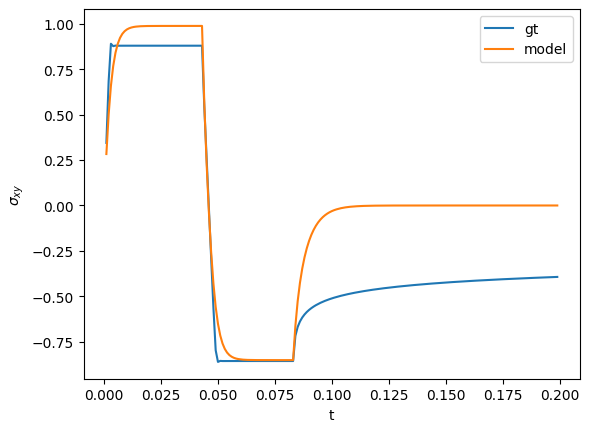

In [11]:
plt.plot(times_train[0:1,1:].T, train_stress[0:1, :, 0, 1].T, label="gt")
plt.plot(times_train[0:1,1:].T, sig_train[0:1, :, 0, 1].T, label="model")
plt.xlabel("t")
plt.ylabel("$\sigma_{xy}$")
plt.legend()
plt.show()

## Training

In [12]:
sig_noise = SymmetricTensor2(tensor=train_stress) # first train on one path

learning_rate = 5e-2
max_steps = 600
optimizer = optax.chain(
    optax.scale_by_adam(),
    optax.scale_by_param_block_rms(),
    optax.scale(-learning_rate),
)

# --- Loss function ---
@eqx.filter_jit
def loss_fn(params, args):
    sig_data, static_ = args
    material_ = params if static_ is None else eqx.combine(params, static_)
    sig_hat = batched_compute_evolution(material_, train_strain, times_train, False)
    diff = sig_hat.array - sig_data.array
    loss_val = 0.5 * jnp.mean(diff**2)
    return loss_val, sig_hat

# --- Gradient step ---
@jax.jit
def step(params, opt_state, args):
    (loss_val, sig_hat), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, args)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_val, sig_hat

# --- Boucle sur gsm / Nvar ---
trainable, static = partition_by_node_names(gsm, ["free_energy.elasticity"])
# trainable, static = eqx.partition(gsm, eqx.is_array)

# initialisation optimizer
params = trainable
opt_state = optimizer.init(params)

# Training loop
for step_idx in range(max_steps):
    params, opt_state, loss_val, sig_hat_train = step(params, opt_state, (sig_noise, static))

    if step_idx % 50 == 0:
        print(f"Step {step_idx}: loss = {float(loss_val):.6e}")

# Combiner trainable + static pour obtenir le matériau complet
trained_material = params if static is None else eqx.combine(params, static)


Step 0: loss = 1.604621e-02
Step 50: loss = 1.012088e-02


KeyboardInterrupt: 

In [57]:
max_steps = 300
# --- Boucle sur gsm / Nvar ---
trainable, static = partition_by_node_names(trained_material, ["free_energy.elasticity"])
# trainable, static = eqx.partition(gsm, eqx.is_array)

# initialisation optimizer
params = trainable
opt_state = optimizer.init(params)

# Training loop
for step_idx in range(max_steps):
    params, opt_state, loss_val, sig_hat_train = step(params, opt_state, (sig_noise, static))

    if step_idx % 50 == 0:
        print(f"Step {step_idx}: loss = {float(loss_val):.6e}")

# Combiner trainable + static pour obtenir le matériau complet
trained_material = params if static is None else eqx.combine(params, static)


Step 0: loss = 2.598728e-05
Step 50: loss = 2.082649e-05
Step 100: loss = 1.702015e-05
Step 150: loss = 1.428754e-05
Step 200: loss = 1.218571e-05
Step 250: loss = 1.059699e-05


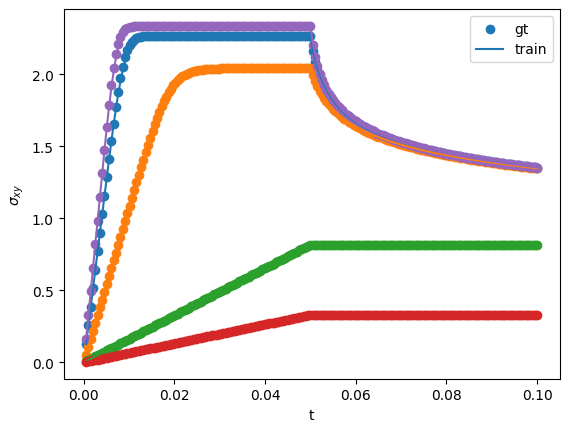

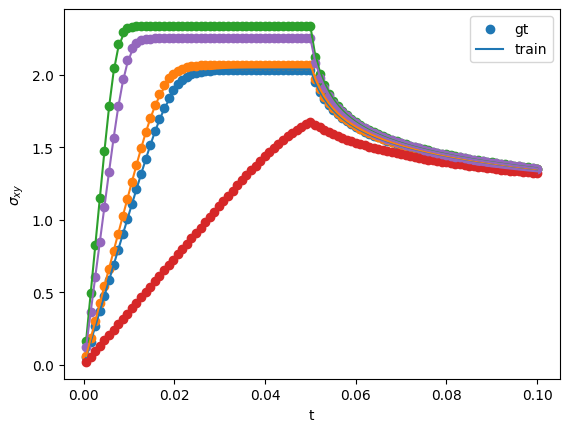

In [117]:
for i in range(5):
    label_gt = 'gt' if i == 0 else None
    label_train = 'train' if i==0 else None
    plt.scatter(times_train[i,1:].T, train_stress[i, :, 0, 1].T, label = label_gt)
    plt.plot(times_train[i,1:].T, sig_hat_train[i, :, 0, 1].T, label = label_train)
plt.xlabel("t")
plt.ylabel("$\sigma_{xy}$")

plt.legend()
plt.show()

sig_hat_test = batched_compute_evolution(trained_material, test_strain, times_test, False)
for i in range(5):
    label_gt = 'gt' if i == 0 else None
    label_train = 'train' if i==0 else None
    plt.scatter(times_test[i,1::2].T, test_stress[i, ::2, 0, 1].T, label = label_gt)
    plt.plot(times_test[i,1::2].T, sig_hat_test[i, ::2, 0, 1].T, label = label_train)
plt.xlabel("t")
plt.ylabel("$\sigma_{xy}$")

plt.legend()
plt.show()

# Conversion for MFront

In [135]:
def evolution(sigma:jnp.array):
    '''
    function that take the 6 composant of epsilon in mandel notation as well as alpha does.'''
    # epsilon = jnp.asarray(epsilon)
    # alpha = jnp.asarray(alpha)
    sigma /= scalers["std_stress"][3]
    sigma_ = SymmetricTensor2(array=sigma)
    dot_isv = trained_material.evolution(sigma_)
    return dot_isv.epsv.array * scalers["std_strain"][3]

def phi2_and_derivatives(sigma):
    """
    Compute dotalpha, dotalpha/depsp and dotalpha/depsp in a single call to JAX.
    """
    phi2 = evolution(sigma)
    J = jax.jacfwd(evolution)(sigma)
    return {"epsp_dot":phi2,"eps_dot_dsig":J}

In [136]:
sigma = jax.random.normal(key=key1, shape=(6,))
epsp = jax.random.normal(key=key2, shape=(6,))
# stress(epsilon, epsp, p)
# evolution(epsilon, epsp, p)
phi2_and_derivatives(sigma)

{'epsp_dot': Array([-8.46536740e-13, -3.06297586e-13,  1.97627111e-12, -2.25328841e-13,
         1.71699074e-12,  2.14229132e-12], dtype=float64),
 'eps_dot_dsig': Array([[ 1.17525459e-12,  8.48328754e-28, -5.47352538e-27,
          6.24075878e-28, -4.75541655e-27, -5.93333871e-27],
        [ 8.48328754e-28,  1.17525459e-12, -1.98045463e-27,
          2.25805835e-28, -1.72062539e-27, -2.14682628e-27],
        [-5.47352538e-27, -1.98045463e-27,  1.17525459e-12,
         -1.45692806e-27,  1.11016946e-26,  1.38515971e-26],
        [ 6.24075878e-28,  2.25805835e-28, -1.45692806e-27,
          1.17525459e-12, -1.26578381e-27, -1.57931992e-27],
        [-4.75541655e-27, -1.72062539e-27,  1.11016946e-26,
         -1.26578381e-27,  1.17525459e-12,  1.20343124e-26],
        [-5.93333871e-27, -2.14682628e-27,  1.38515971e-26,
         -1.57931992e-27,  1.20343124e-26,  1.17525459e-12]],      dtype=float64)}

In [137]:
from jax.experimental import jax2tf
import tensorflow as tf

# --- Conversion d'évolution (phi2) ---
phi2_tf = tf.function(
    jax2tf.convert(phi2_and_derivatives, with_gradient=False, enable_xla=False),
    input_signature=[
        tf.TensorSpec(shape=(6,), dtype=tf.float64, name="sigma"),
    ],
)

In [138]:
class ConstitutiveModel(tf.Module):
    def __init__(self):
        super().__init__()
        # self.phi1 = phi1_tf
        self.phi2 = phi2_tf

model = ConstitutiveModel()

In [139]:
sig = tf.zeros((6,), dtype=tf.float64)

phi2 = model.phi2(sig)

print("phi_2:", phi2)

tf.saved_model.save(
    model,
    export_dir="./model/norton_nn",
    signatures={
        "phi2": model.phi2
    }
)

phi_2: {'eps_dot_dsig': <tf.Tensor: shape=(6, 6), dtype=float64, numpy=
array([[1.17525459e-12, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.17525459e-12, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.17525459e-12, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.17525459e-12,
        0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.17525459e-12, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.17525459e-12]])>, 'epsp_dot': <tf.Tensor: shape=(6,), dtype=float64, numpy=array([0., 0., 0., 0., 0., 0.])>}
INFO:tensorflow:Assets written to: ./model/norton_nn/assets


INFO:tensorflow:Assets written to: ./model/norton_nn/assets
